In [8]:
import pandas as pd

oab_with_irac_df = pd.read_csv("../data/processed/oab_with_irac.csv")

oab_with_irac_df.shape

(5, 20)

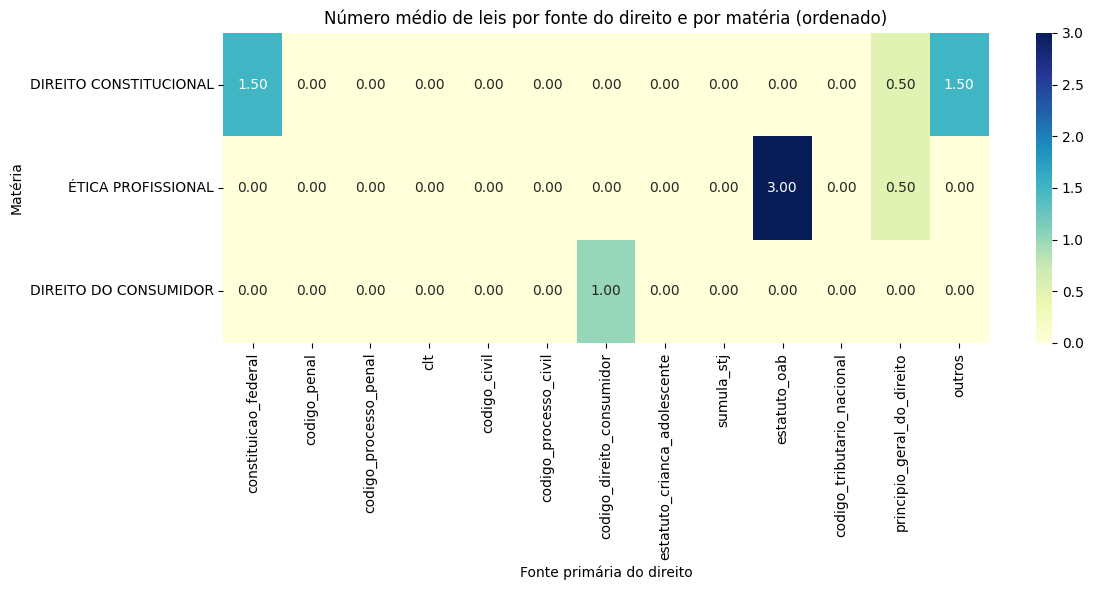

In [9]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Converter a coluna 'Rule' (string JSON) para dicionário Python
oab_with_irac_df["Rule_dict"] = oab_with_irac_df["Rule"].apply(json.loads)

# 2. Contar o número de leis por fonte do direito (nível 1 do JSON)
def contar_leis_por_fonte(rule_dict):
    return {fonte: len(itens) for fonte, itens in rule_dict.items() if isinstance(itens, list)}

oab_with_irac_df["leis_por_fonte"] = oab_with_irac_df["Rule_dict"].apply(contar_leis_por_fonte)

# 3. Expandir a coluna 'leis_por_fonte' em colunas separadas
leis_df = oab_with_irac_df[["materia", "leis_por_fonte"]].copy()
leis_expandidas = leis_df["leis_por_fonte"].apply(pd.Series)
leis_expandidas["materia"] = leis_df["materia"]

# 4. Agrupar por matéria e calcular a média de leis por fonte
media_leis_por_materia = leis_expandidas.groupby("materia").mean(numeric_only=True)

# 5. Calcular o total médio de leis por matéria e ordenar
media_leis_por_materia["total_medio"] = media_leis_por_materia.sum(axis=1)
media_leis_por_materia = media_leis_por_materia.sort_values("total_medio", ascending=False)
media_leis_ordenadas = media_leis_por_materia.drop(columns="total_medio")

# 6. Plotar o heatmap ordenado
plt.figure(figsize=(12, 6))
sns.heatmap(media_leis_ordenadas, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Número médio de leis por fonte do direito e por matéria (ordenado)")
plt.xlabel("Fonte primária do direito")
plt.ylabel("Matéria")
plt.tight_layout()
plt.show()


In [10]:
# Função recursiva para coletar todas as ocorrências da chave "lei"
def encontrar_todas_leis(json_string):
    dados = json.loads(json_string)
    leis_encontradas = []

    for categoria in dados.values():
        if categoria == None:
            continue
        for item in categoria:
            if isinstance(item, dict) and "lei" in item:
                leis_encontradas.append(item["lei"])

    return leis_encontradas


rule = """
{"constituicao_federal": [{"lei": "lei tal da CF"}], "codigo_penal": [], "codigo_processo_penal": [], "clt": [], "codigo_civil": [{"lei": "Art. 733 do C\u00f3digo Civil", "conteudo": "Nos contratos de transporte cumulativo, cada transportador se obriga a cumprir o contrato relativamente ao respectivo percurso, respondendo pelos danos nele causados a pessoas e coisas."}], "codigo_processo_civil": [], "sumula_stj": [], "estatuto_oab": [], "codigo_tributario_nacional": [], "principio_geral_do_direito": [], "outros": [{"lei": "Art. 2\u00ba da Lei n\u00ba 9.611/98", "conteudo": "Transporte Multimodal de Cargas \u00e9 aquele que, regido por um \u00fanico contrato, utiliza duas ou mais modalidades de transporte, desde a origem at\u00e9 o destino."}, {"lei": "Conceito de Contrato de Transporte Combinado", "conteudo": "No contrato de transporte combinado o transportador assume a obriga\u00e7\u00e3o de transportar a coisa no seu trecho, assumindo, perante o cliente, a obriga\u00e7\u00e3o de contratar terceiros para a continua\u00e7\u00e3o do transporte em outros trechos."}, {"lei": "Conceito de Transporte de Fato", "conteudo": "O transporte de fato se d\u00e1 quando realizado por pessoa distinta do transportador constante do contrato, autorizado por este a efetuar o transporte integral ou parcialmente."}]}
"""
assert len(encontrar_todas_leis(rule)) == 5
assert len(encontrar_todas_leis("{}")) == 0
assert len(encontrar_todas_leis("""{"constituicao_federal": null, "codigo_penal": null}""")) == 0

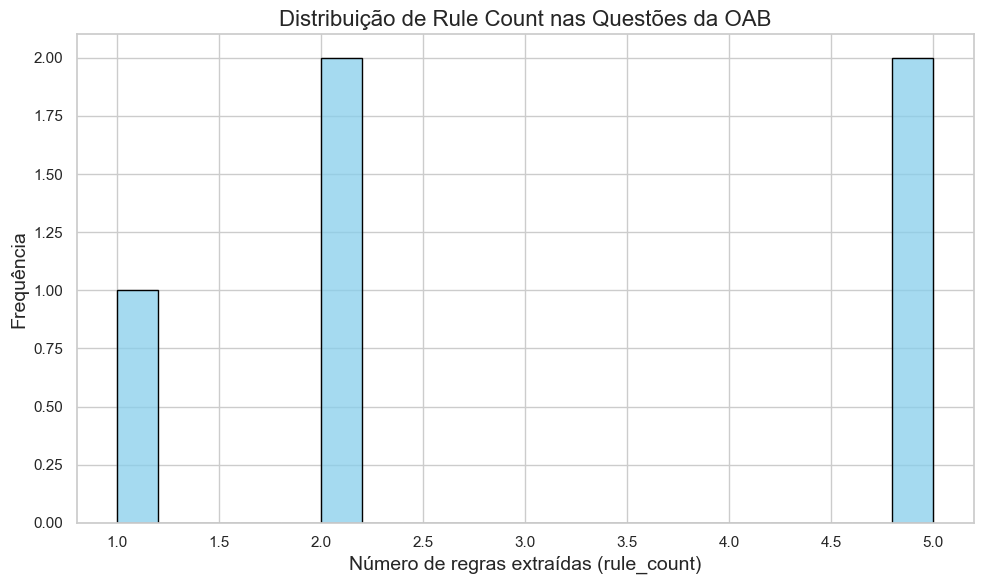

In [11]:
'''
prompt:
Plote código que posta um histograma de rule_count em oab_with_irac_df

'''

import matplotlib.pyplot as plt
import seaborn as sns

# Configura estilo
sns.set(style="whitegrid")

# Plota histograma
plt.figure(figsize=(10, 6))
sns.histplot(oab_with_irac_df['rule_count'], bins=20, kde=False, color='skyblue', edgecolor='black')

# Títulos e rótulos
plt.title('Distribuição de Rule Count nas Questões da OAB', fontsize=16)
plt.xlabel('Número de regras extraídas (rule_count)', fontsize=14)
plt.ylabel('Frequência', fontsize=14)

# Exibe o gráfico
plt.tight_layout()
plt.show()
